In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings('ignore')

colormap = sns.color_palette("Blues")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({'font.size': 22})
sns.set(font_scale=2.4)

In [2]:
AGENTS = [
    "Qwen/Qwen2.5-7B-Instruct",
    "meta-llama/Meta-Llama-3-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.2",
]
AGENTS_CLEAN_NAMES = ["Qwen2.5-7B", "Llama-3-8B", "Mistral-7B"]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

LOGS_ROOT = ".logs/small_models"

#### Utils

In [3]:
def load_games_from_dir(log_dir):
    """Walk log_dir recursively, load every game_state.json that reached END."""
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    """Sum all values in a resource dict."""
    return sum(res["_value"].values())


def replace_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df

## Trading

In [4]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "trading_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_names(pd.DataFrame(rows))
trading_df.head()

Found 226 completed games in .logs/small_models/trading_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,TradingGame,Qwen2.5-7B,Qwen2.5-7B,-8,8
1,TradingGame,Qwen2.5-7B,Qwen2.5-7B,20,-20
2,TradingGame,Qwen2.5-7B,Qwen2.5-7B,10,-10
3,TradingGame,Qwen2.5-7B,Qwen2.5-7B,5,-5
4,TradingGame,Qwen2.5-7B,Qwen2.5-7B,10,-10


In [5]:
def trading_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    agg["win_1"] = agg["win_1"] / (agg["win_1"] + agg["win_2"])
    agg["win_2"] = agg["win_2"] / (agg["win_1"] + agg["win_2"])
    return agg


aggregated = trading_aggregation(trading_df)

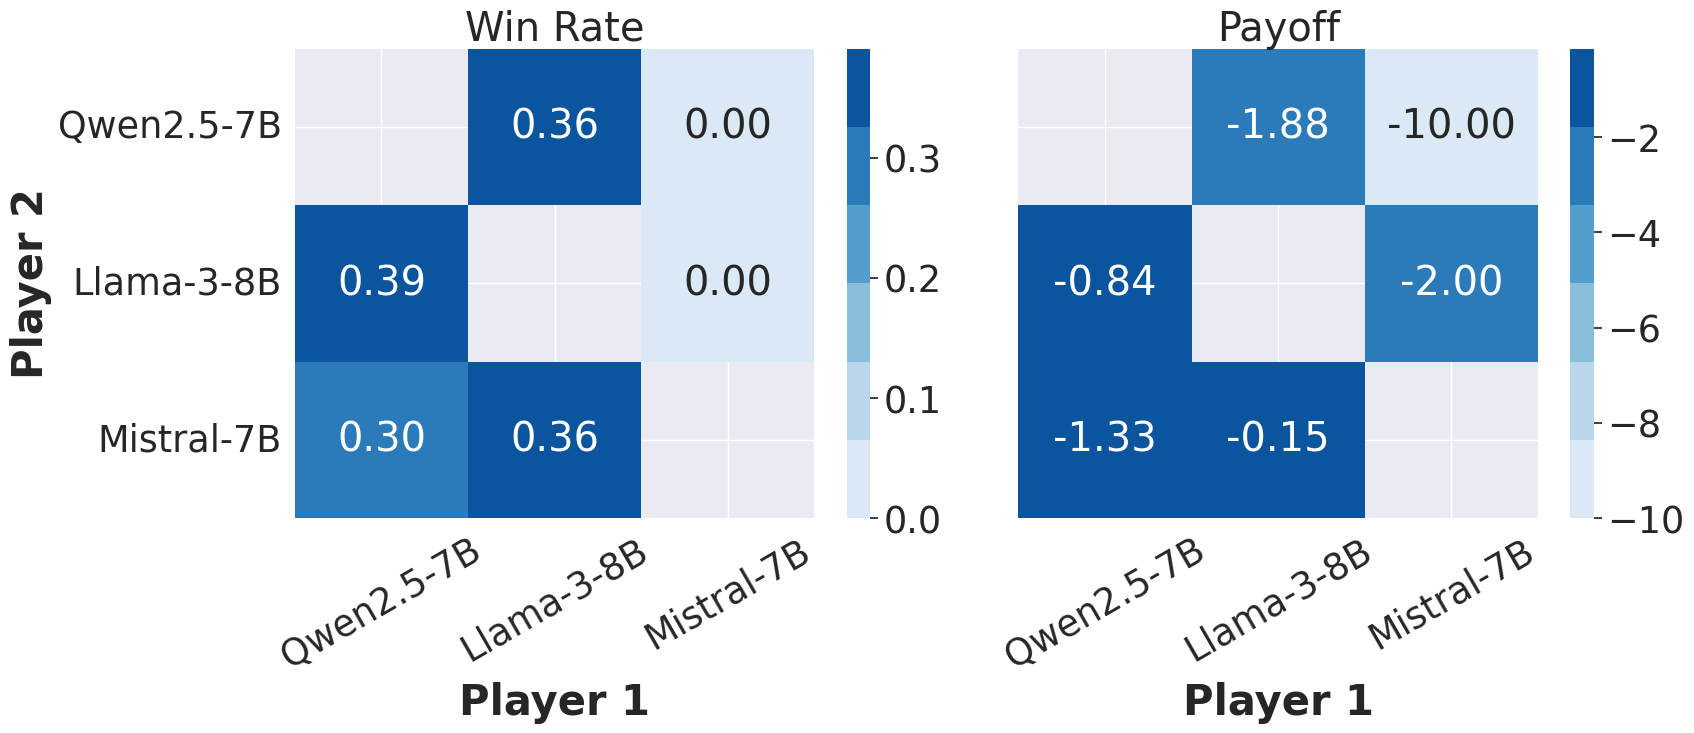

In [6]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)
fig.tight_layout()

# Win Rate heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="win_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)
mask = np.eye(len(AGENTS_CLEAN_NAMES), dtype=bool)

p1 = sns.heatmap(local, annot=True, mask=mask, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_ylabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_title("Win Rate")
p1.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)

# Payoff heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="resource_delta_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, mask=mask, fmt=".2f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)
p2.set_yticklabels(labels=[])

fig.tight_layout()
plt.savefig("_notebooks/figures/oss_trading.pdf", bbox_inches="tight")
plt.show()

## Ultimatum

In [7]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "ultimatum_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_names(pd.DataFrame(rows))

# P1 starts with $100, adjust so resource_delta_1 = amount P1 keeps
ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
# If delta+100 == 100 (no deal happened), set to 0
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

ultimatum_df.head()

Found 283 completed games in .logs/small_models/ultimatum_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,MultiTurnUltimatumGame,Qwen2.5-7B,Qwen2.5-7B,50,50
1,MultiTurnUltimatumGame,Qwen2.5-7B,Qwen2.5-7B,0,0
2,MultiTurnUltimatumGame,Qwen2.5-7B,Qwen2.5-7B,90,10
3,MultiTurnUltimatumGame,Qwen2.5-7B,Qwen2.5-7B,101,-1
4,MultiTurnUltimatumGame,Qwen2.5-7B,Qwen2.5-7B,0,0


In [8]:
def ultimatum_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    agg["win_1"] = agg["win_1"] / (agg["win_1"] + agg["win_2"])
    agg["win_2"] = agg["win_2"] / (agg["win_1"] + agg["win_2"])
    return agg


aggregated = ultimatum_aggregation(ultimatum_df)

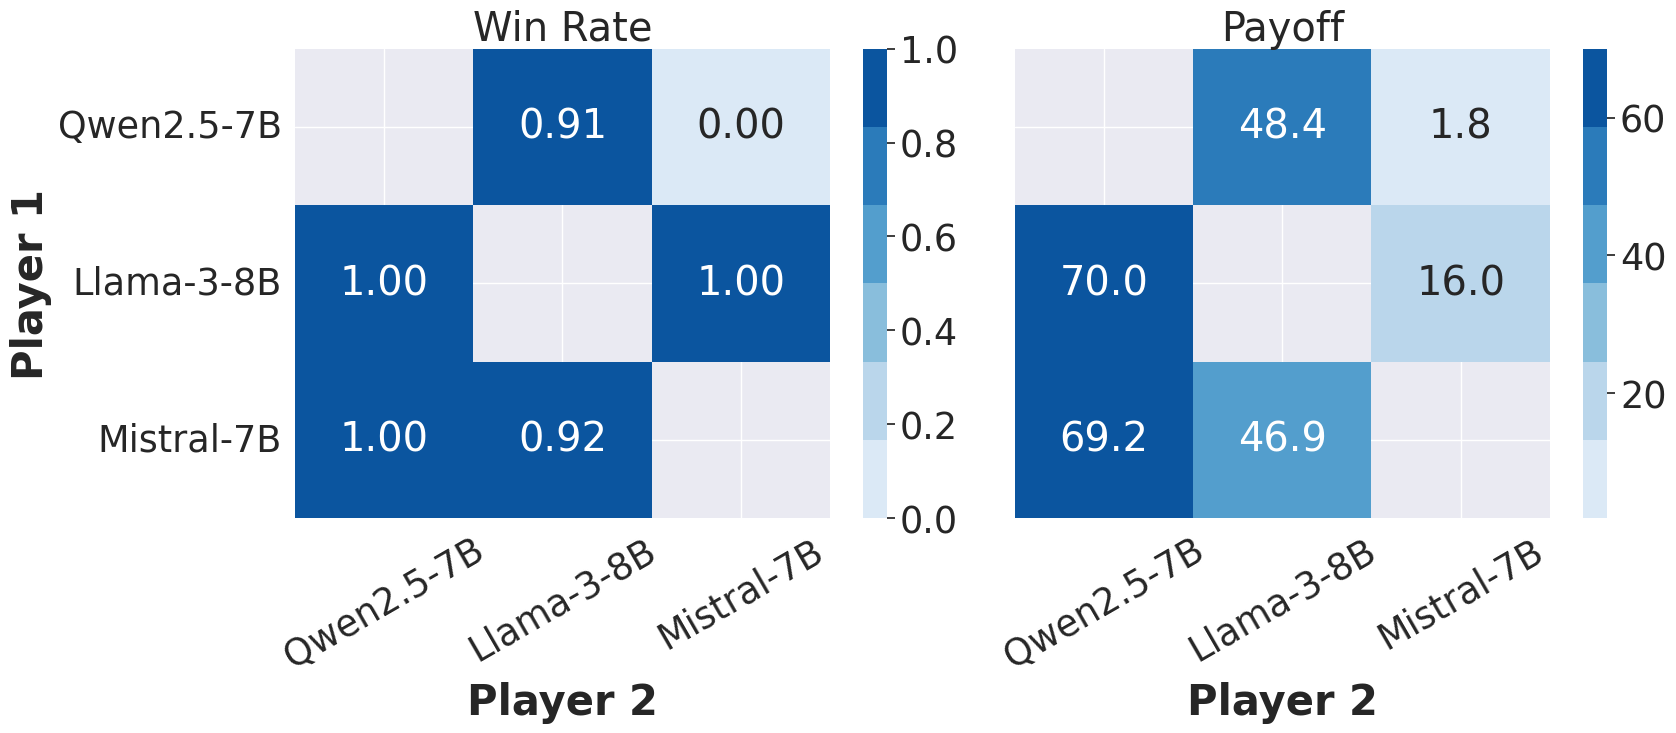

In [9]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)
fig.tight_layout()

# Win Rate heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="win_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)
mask = np.eye(len(AGENTS_CLEAN_NAMES), dtype=bool)

p1 = sns.heatmap(local, annot=True, mask=mask, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_title("Win Rate")
p1.set_ylabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)

# Payoff heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="resource_delta_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, mask=mask, fmt=".1f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 2", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(labels=AGENTS_CLEAN_NAMES, rotation=30)
p2.set_yticklabels(labels=[])

fig.tight_layout()
plt.savefig("_notebooks/figures/oss_ultimatum.pdf", bbox_inches="tight")
plt.show()

## Seller and Buyer

In [10]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "buysell_section_one"))

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s["player_valuation"]
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_names(pd.DataFrame(rows))
buysell_df.head()

Found 117 completed games in .logs/small_models/buysell_section_one


,game_name,model_1,model_2,outcome_1,outcome_2,vals1,vals2
0,BuySellGame,Qwen2.5-7B,Qwen2.5-7B,5,15,40,60
1,BuySellGame,Qwen2.5-7B,Qwen2.5-7B,10,10,40,60
2,BuySellGame,Qwen2.5-7B,Qwen2.5-7B,10,10,40,60
3,BuySellGame,Qwen2.5-7B,Qwen2.5-7B,0,20,40,60
4,BuySellGame,Qwen2.5-7B,Qwen2.5-7B,10,10,40,60


In [11]:
gb = buysell_df.groupby("vals1")
groups = {k: v.copy() for k, v in gb}
print("Available seller valuations:", list(groups.keys()))

seller_at_40 = groups[40]
print(f"Seller at 40 (buyer at 60): {len(seller_at_40)} games")

Available seller valuations: [40]
Seller at 40 (buyer at 60): 117 games


Filtered 3 outlier games


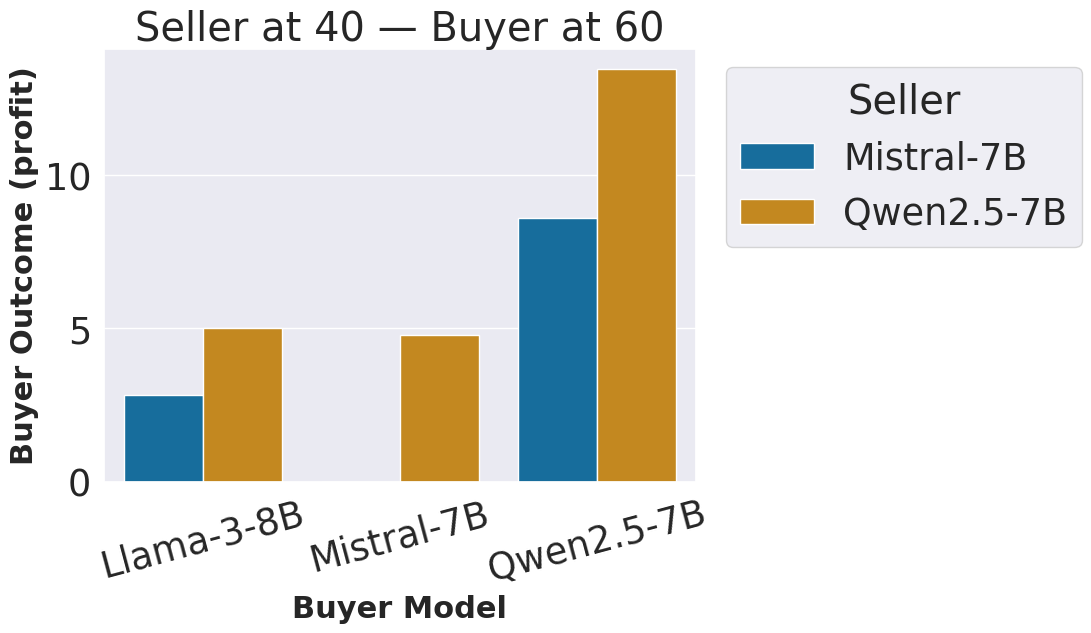

    seller      buyer  outcome_mean  outcome_sem  n
Mistral-7B Llama-3-8B      2.809524     1.682712 21
Mistral-7B Mistral-7B      0.000000     0.000000 24
Mistral-7B Qwen2.5-7B      8.607143     1.333670 28
Qwen2.5-7B Llama-3-8B      5.000000     5.088502  8
Qwen2.5-7B Mistral-7B      4.769231     1.833289 13
Qwen2.5-7B Qwen2.5-7B     13.444444     0.933131 18


In [12]:
# Filter out broken games where outcomes exceed valid range
# Max buyer profit is 60 (buys at 0 with valuation 60), min is -100 (pays 100 for item worth 60)
valid = seller_at_40[(seller_at_40["outcome_2"] >= -100) & (seller_at_40["outcome_2"] <= 60)]
print(f"Filtered {len(seller_at_40) - len(valid)} outlier games")

agg = valid.groupby(["model_1", "model_2"])["outcome_2"].agg(["mean", "sem", "count"]).reset_index()
agg.columns = ["seller", "buyer", "outcome_mean", "outcome_sem", "n"]
agg = agg[agg["n"] >= 2]

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(data=agg, x="buyer", y="outcome_mean", hue="seller",
            palette="colorblind", capsize=0.1, ax=ax)

ax.set_ylabel("Buyer Outcome (profit)", fontdict=dict(weight="bold", size=22))
ax.set_xlabel("Buyer Model", fontdict=dict(weight="bold", size=22))
ax.set_title("Seller at 40 — Buyer at 60")
ax.legend(title="Seller", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=15)

fig.tight_layout()
fig.savefig("_notebooks/figures/oss_seller_at_40.pdf", bbox_inches="tight")
plt.show()

print(agg.to_string(index=False))